In [ ]:
import tensorflow as tf
import os
from PIL import Image
import numpy as np
from tqdm import tqdm

# Базовые пути
BASE_DIR = './tfrecords-jpeg-224x224'
OUTPUT_DIR = './data'

def parse_tfrecord(example):
    """Парсинг TFRecord с метками (train/val)"""
    features = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'class': tf.io.FixedLenFeature([], tf.int64),
    }
    parsed = tf.io.parse_single_example(example, features)
    image = tf.io.decode_jpeg(parsed['image'], channels=3)
    label = parsed['class']
    return image, label

def parse_test_tfrecord(example):
    """Парсинг TFRecord без меток (test)"""
    features = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'id': tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example, features)
    image = tf.io.decode_jpeg(parsed['image'], channels=3)
    img_id = parsed['id']
    return image, img_id

def convert_split(split_name, has_labels=True):
    """Конвертация одной папки (train/val/test)"""
    tfrecords_dir = os.path.join(BASE_DIR, split_name)
    output_split_dir = os.path.join(OUTPUT_DIR, split_name)
    os.makedirs(output_split_dir, exist_ok=True)
    
    tfrecord_files = [f for f in os.listdir(tfrecords_dir) if f.endswith('.tfrec')]
    print(f"Обработка {split_name}: найдено {len(tfrecord_files)} TFRecord файлов")
    
    image_counter = 0
    
    for tfrecord_file in tqdm(tfrecord_files, desc=f"Конвертация {split_name}"):
        tfrecord_path = os.path.join(tfrecords_dir, tfrecord_file)
        dataset = tf.data.TFRecordDataset(tfrecord_path)
        
        if has_labels:
            parsed_dataset = dataset.map(parse_tfrecord)
            for image, label in parsed_dataset:
                image_np = image.numpy()
                label_np = label.numpy()
                
                class_dir = os.path.join(output_split_dir, f'class_{label_np}')
                os.makedirs(class_dir, exist_ok=True)
                
                img = Image.fromarray(image_np)
                img_path = os.path.join(class_dir, f'image_{image_counter:05d}.jpg')
                img.save(img_path)
                image_counter += 1
        else:
            parsed_dataset = dataset.map(parse_test_tfrecord)
            for image, img_id in parsed_dataset:
                image_np = image.numpy()
                img_id_str = img_id.numpy().decode('utf-8')
                
                img = Image.fromarray(image_np)
                img_path = os.path.join(output_split_dir, f'{img_id_str}.jpg')
                img.save(img_path)
                image_counter += 1
    
    print(f" {split_name}: сохранено {image_counter} изображений\n")
    return image_counter

if __name__ == "__main__":
    print("Начинаем конвертацию всех данных...\n")
    
    train_count = convert_split('train', has_labels=True)
    val_count = convert_split('val', has_labels=True)
    test_count = convert_split('test', has_labels=False)
    
    print(f"\n Конвертация завершена!")
    print(f"   Train: {train_count} изображений")
    print(f"   Val: {val_count} изображений")
    print(f"   Test: {test_count} изображений")

Начинаем конвертацию всех данных...

Обработка train: найдено 16 TFRecord файлов


Конвертация train: 100%|██████████| 16/16 [00:28<00:00,  1.79s/it]


✅ train: сохранено 12753 изображений

Обработка val: найдено 16 TFRecord файлов


Конвертация val: 100%|██████████| 16/16 [00:08<00:00,  1.84it/s]


✅ val: сохранено 3712 изображений

Обработка test: найдено 16 TFRecord файлов


Конвертация test: 100%|██████████| 16/16 [00:14<00:00,  1.07it/s]

✅ test: сохранено 7382 изображений


🎉 Конвертация завершена!
   Train: 12753 изображений
   Val: 3712 изображений
   Test: 7382 изображений


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Используем устройство: {device}")

 Используем устройство: cuda


In [ ]:
IMG_SIZE = 224  # оптимально для GTX 1050
BATCH_SIZE = 16  

# Аугментации для обучения
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),  
    transforms.RandomRotation(25),     
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Аугментации для валидации ( ресайз и нормализация)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from torchvision import datasets
from sklearn.metrics import f1_score

train_dir = './data/train'  
val_dir = './data/val'

print("Загрузка данных...")


train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"   Данные загружены!")
print(f"   Train: {len(train_dataset)} изображений, {len(train_loader)} батчей")
print(f"   Val: {len(val_dataset)} изображений, {len(val_loader)} батчей")
print(f"   Классов: {len(train_dataset.classes)}")

Загрузка данных...
✅ Данные загружены!
   Train: 12753 изображений, 798 батчей
   Val: 3712 изображений, 232 батчей
   Классов: 104


In [ ]:

# EfficientNet-B0 БЕЗ предобученных весов (обучение с нуля)
print(" Создание модели EfficientNet-B0 ")
model = torchvision.models.efficientnet_b0(weights=None)

num_classes = len(train_dataset.classes)

# EfficientNet имеет другую структуру классификатора
# Заменяем последний линейный слой (было 1000 классов ImageNet, стало 104)
model.classifier[1] = nn.Linear(1280, num_classes)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Модель EfficientNet-B0 готова!")
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")
print(f"   Вход: 3×{IMG_SIZE}×{IMG_SIZE}")
print(f"   Выход: {num_classes} классов")
print(f"   Устройство: {device}")
print(f" Модель с Dropout готова!")
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")

 Создание модели EfficientNet-B0 с нуля...
✅ Модель EfficientNet-B0 готова!
   Всего параметров: 4,140,772
   Обучаемых параметров: 4,140,772
   Вход: 3×224×224
   Выход: 104 классов
   Устройство: cuda
✅ Модель с Dropout готова!
   Всего параметров: 4,140,772
   Обучаемых параметров: 4,140,772


In [7]:
EPOCHS = 40  # Количество эпох
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=EPOCHS):
    best_model_wts = copy.deepcopy(model.state_dict()) 
    best_F1 = 0.0
    
    history = {
        'train_loss': [], 'train_F1': [],
        'val_loss': [], 'val_F1': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  #обучение
                dataloader = train_loader
            else:
                model.eval()   # оценка
                dataloader = val_loader

            running_loss = 0.0
            all_preds=[]
            all_labels=[]
            

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if phase == 'train':
                scheduler.step(epoch_F1)
                import time

                if epoch % 2 == 0: 
                    print("️ Пауза 30 секунд для охлаждения.")
                    time.sleep(30)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_F1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Macro F1: {epoch_F1:.4f}')
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_F1'].append(epoch_F1)

            if phase == 'val' and epoch_F1 > best_F1:
                best_F1 = epoch_F1
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"  Новый лучший Macro F1: {best_F1:.4f}. Сохраняем веса.")

    print(f'\n Best val Macro F1: {best_F1:.4f}')

    model.load_state_dict(best_model_wts)
    
    return model, history

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    

    ax1.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', marker='s', color='orange')
    ax1.set_title('Model Loss (Ошибка)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
   
    ax2.plot(history['train_F1'], label='Train Macro F1', marker='o', color='blue')
    ax2.plot(history['val_F1'], label='Val Macro F1', marker='s', color='orange')
    ax2.set_title('Model Macro F1 Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [ ]:

trained_model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=EPOCHS)


Epoch 1/40
----------


TypeError: ReduceLROnPlateau.step() missing 1 required positional argument: 'metrics'

In [ ]:
def continue_training(model, criterion, optimizer, scheduler, history, additional_epochs=20):
    best_F1 = max(history['val_F1']) if history['val_F1'] else 0.0
    start_epoch = len(history['train_loss'])
    total_epochs = start_epoch + additional_epochs

    print(f" Продолжаем обучение с эпохи {start_epoch + 1}")
    print(f" Добавляем {additional_epochs} эпох (итого будет {total_epochs})")
    print(f" Лучший Val Macro F1 до продолжения: {best_F1:.4f}")
    print("=" * 50)

    for epoch in range(additional_epochs):
        current_epoch = start_epoch + epoch + 1
        print(f'\nEpoch {current_epoch}/{total_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_F1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Macro F1: {epoch_F1:.4f}')

          
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_F1'].append(epoch_F1)

            if phase == 'val' and epoch_F1 > best_F1:
                best_F1 = epoch_F1
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"  ⭐ Новый лучший Macro F1: {best_F1:.4f}. Сохраняем веса...")

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(history['val_F1'][-1])  # Use validation F1
        else:
            scheduler.step()

        
        if epoch % 3 == 0:
            print("Пауза 20 секунд для охлаждения...")
            time.sleep(20)
            torch.cuda.empty_cache()

    print(f'\n Лучший Val Macro F1 за всё обучение: {best_F1:.4f}')
    print(f' Всего эпох обучено: {len(history["train_loss"])}')

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:

trained_model, history = continue_training(
    trained_model, 
    criterion, 
    optimizer, 
    scheduler, 
    history, 
    additional_epochs=20
)


NameError: name 'trained_model' is not defined

In [ ]:

trained_model, history = continue_training(
    trained_model, 
    criterion, 
    optimizer, 
    scheduler, 
    history, 
    additional_epochs=20
)


🔄 Продолжаем обучение с эпохи 61
📊 Добавляем 20 эпох (итого будет 80)
🏆 Лучший Val Macro F1 до продолжения: 0.6916

Epoch 61/80
----------
train Loss: 1.9146 Macro F1: 0.6120
val Loss: 1.9364 Macro F1: 0.6060
⏸️ Пауза 20 секунд для охлаждения...

Epoch 62/80
----------
train Loss: 1.8965 Macro F1: 0.6253
val Loss: 1.9163 Macro F1: 0.6046

Epoch 63/80
----------
train Loss: 1.8635 Macro F1: 0.6371
val Loss: 1.8600 Macro F1: 0.6650

Epoch 64/80
----------
train Loss: 1.8319 Macro F1: 0.6588
val Loss: 1.8739 Macro F1: 0.6295
⏸️ Пауза 20 секунд для охлаждения...

Epoch 65/80
----------
train Loss: 1.8021 Macro F1: 0.6640
val Loss: 1.8126 Macro F1: 0.6646

Epoch 66/80
----------
train Loss: 1.7583 Macro F1: 0.6857
val Loss: 1.8725 Macro F1: 0.6515

Epoch 67/80
----------
train Loss: 1.7474 Macro F1: 0.6882
val Loss: 1.8324 Macro F1: 0.6595
⏸️ Пауза 20 секунд для охлаждения...

Epoch 68/80
----------


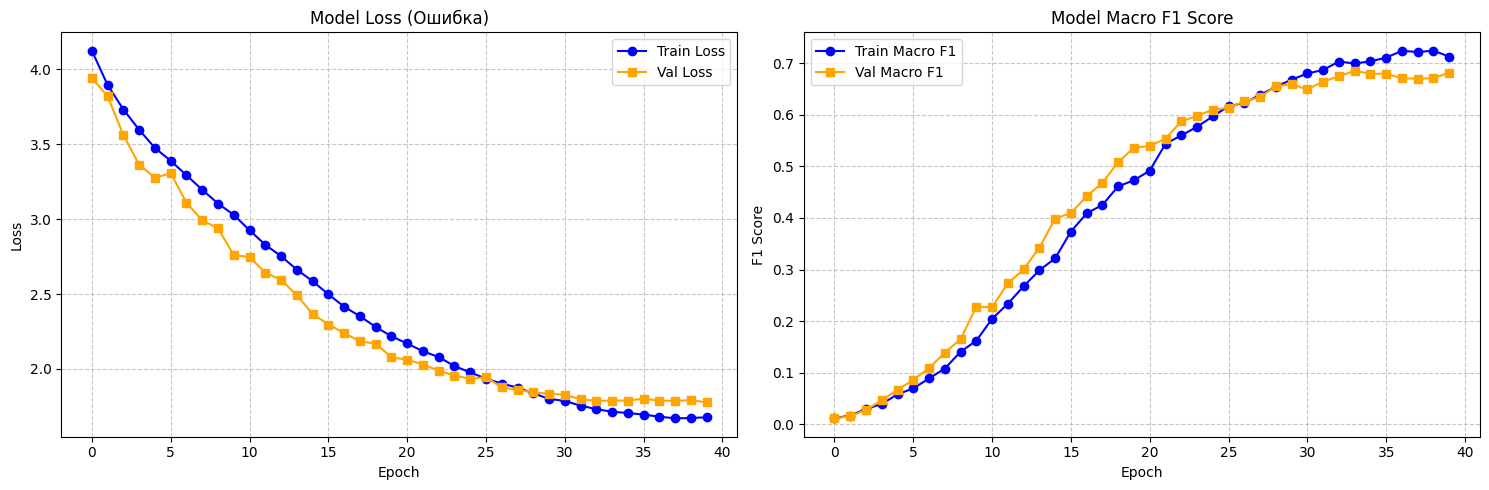

 Модель сохранена в файл 'best_flower_model.pth'


In [ ]:

plot_training_history(history)

torch.save(trained_model.state_dict(), 'best_flower_model.pth')
print(" Модель сохранена в файл 'best_flower_model.pth'")